# GPyro 개발용 프로토타입 (노트북)

**논문:** *GPyro: uncertainty-aware temperature predictions for additive manufacturing* (Sideris et al., 2023)

이 노트북은 `gpyro_prototype` 패키지를 사용해 **실험 여러 개(기본 T1~T10)를 시간 순으로 이어 붙인** 데이터를 로드하고, train/val/test 분할 후 소형 MLP를 학습하며, **DTW 기반 평균 절대 상대오차(DTW-MARE)**를 보고합니다.

> 최종 논문 재현이 아니라 **개발·탐색용**입니다. 실행 전 작업 디렉터리를 `Reflow_Article`로 두거나, 아래 셀에서 경로만 수정하세요.

In [8]:
from __future__ import annotations

import sys
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

# 프로젝트 루트(이 노트북이 있는 폴더 = Reflow_Article)를 path에 추가
ROOT = Path.cwd().resolve()
for p in [ROOT, *ROOT.parents]:
    if (p / "gpyro_prototype" / "loaders.py").is_file():
        ROOT = p
        break
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from gpyro_prototype.config import DEFAULT_EXPERIMENT_IDS, PrototypeConfig
from gpyro_prototype.dataset import ThermalSequenceDataset, bundle_to_numpy, contiguous_split_indices
from gpyro_prototype.loaders import (
    build_aligned_matrix,
    merge_aligned_bundles,
    read_coordinates,
    read_recorded_points,
    read_temperatures_corrected,
)
from gpyro_prototype.train import autoregressive_rollout, cap_rollout_horizon
from gpyro_prototype.metrics import aggregate_dtw_mare_over_nodes, mae_rmse
from gpyro_prototype.model import ThermalMLP, build_features

print("ROOT =", ROOT)
print("torch", torch.__version__, "cuda:", torch.cuda.is_available())

ImportError: cannot import name 'DEFAULT_EXPERIMENT_IDS' from 'gpyro_prototype.config' (C:\Users\USER\Downloads\KG 석도\Reflow_Article\gpyro_prototype\config.py)

## 설정

- `experiment_ids`: 기본 `T1`~`T10` (시간 순으로 이어 붙임; 경계 스텝은 학습에서 제외)
- `epochs`, `rollout_horizon`, `dtw_subsample_stride` 등은 개발 속도에 맞게 조정

In [ ]:
DATA_ROOT = ROOT / "GPyro-TD"

cfg = PrototypeConfig(
    data_root=DATA_ROOT,
    experiment_ids=DEFAULT_EXPERIMENT_IDS,
    train_frac=0.70,
    val_frac=0.15,
    epochs=15,
    batch_size=64,
    lr=1e-3,
    hidden_dim=256,
    rollout_horizon=48,
    dtw_subsample_stride=8,
    relative_eps_c=1.0,
    seed=42,
)

print("experiments:", cfg.experiment_ids)
print("example paths:", cfg.temperatures_path("T1"), cfg.coordinates_path("T1"))

temperatures: C:\Users\USER\Downloads\KG 석도\Reflow_Article\GPyro-TD\temperatures\T1_corrected.csv
coordinates: C:\Users\USER\Downloads\KG 석도\Reflow_Article\GPyro-TD\Coordinate_Time\Coordinates_T1.csv


## 데이터 로드 및 정렬

보정 온도(`*_corrected.csv`)는 세미콜론·유럽식 소수점, 좌표는 시간축에 보간됩니다.

In [ ]:
recorded = read_recorded_points(cfg.recorded_points_path)
bundles_single = []
for eid in cfg.experiment_ids:
    temps = read_temperatures_corrected(cfg.temperatures_path(eid))
    coords = read_coordinates(cfg.coordinates_path(eid))
    bundles_single.append(build_aligned_matrix(temps, coords, recorded))
bundle = bundle_to_numpy(merge_aligned_bundles(bundles_single, list(cfg.experiment_ids)))

n = len(bundle["T"])
print("T shape:", bundle["T"].shape, "time steps (merged):", n)
print("segment_starts:", bundle["segment_starts"])
split = contiguous_split_indices(n, cfg.train_frac, cfg.val_frac)
print("split (contiguous):", split.train, split.val, split.test)

T shape: (26478, 81) time steps: 26478
split (contiguous): slice(0, 18533, None) slice(18534, 22504, None) slice(22505, 26477, None)


## 학습 (1-step ahead MSE)

In [ ]:
# autoregressive_rollout, cap_rollout_horizon 은 위에서 train 모듈에서 import

torch.manual_seed(cfg.seed)
np.random.seed(cfg.seed)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

sample_feat, _ = ThermalSequenceDataset(bundle, split.train)[0]
in_dim = int(sample_feat.shape[0])
n_nodes = bundle["T"].shape[1]
model = ThermalMLP(in_dim=in_dim, out_dim=n_nodes, hidden=cfg.hidden_dim).to(device)

train_ds = ThermalSequenceDataset(bundle, split.train)
val_ds = ThermalSequenceDataset(bundle, split.val)
train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=False)
val_loader = DataLoader(val_ds, batch_size=cfg.batch_size, shuffle=False)

opt = torch.optim.Adam(model.parameters(), lr=cfg.lr)
loss_fn = nn.MSELoss()

history = {"train_mse": [], "val_mse": []}
for ep in range(1, cfg.epochs + 1):
    model.train()
    tr_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad(set_to_none=True)
        pred = model(xb)
        loss = loss_fn(pred, yb)
        loss.backward()
        opt.step()
        tr_loss += float(loss.item()) * len(xb)
    tr_loss /= len(train_ds)
    model.eval()
    va_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb)
            va_loss += float(loss_fn(pred, yb).item()) * len(xb)
    va_loss /= max(1, len(val_ds))
    history["train_mse"].append(tr_loss)
    history["val_mse"].append(va_loss)
    print(f"epoch {ep:03d}  train_mse={tr_loss:.6f}  val_mse={va_loss:.6f}")

epoch 001  train_mse=3654.318224  val_mse=4360.714545
epoch 002  train_mse=5032.851733  val_mse=5417.099362
epoch 003  train_mse=5694.162723  val_mse=3428.368053
epoch 004  train_mse=4907.265823  val_mse=3503.229656
epoch 005  train_mse=5349.922845  val_mse=2991.765761
epoch 006  train_mse=4309.463035  val_mse=2506.788730
epoch 007  train_mse=3665.738446  val_mse=2357.471207
epoch 008  train_mse=3202.668584  val_mse=2842.694015
epoch 009  train_mse=2636.215521  val_mse=2789.721450
epoch 010  train_mse=2226.682647  val_mse=9531.155628
epoch 011  train_mse=2266.370415  val_mse=7606.227533
epoch 012  train_mse=2412.263109  val_mse=6145.655502
epoch 013  train_mse=1986.024939  val_mse=9613.061893
epoch 014  train_mse=1871.923204  val_mse=4716.636192
epoch 015  train_mse=1862.047804  val_mse=3649.262374


## 평가: DTW-MARE (주 지표) + MAE/RMSE + 짧은 rollout

In [ ]:
test_ds = ThermalSequenceDataset(bundle, split.test)
test_loader = DataLoader(test_ds, batch_size=cfg.batch_size, shuffle=False)
model.eval()
preds_one, trues_one = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        pred = model(xb)
        preds_one.append(pred.cpu().numpy())
        trues_one.append(yb.numpy())

y_pred_1 = np.concatenate(preds_one, axis=0)
y_true_1 = np.concatenate(trues_one, axis=0)
mae_1, rmse_1 = mae_rmse(y_true_1, y_pred_1)

dtw_mare, per_node = aggregate_dtw_mare_over_nodes(
    y_true_1,
    y_pred_1,
    eps_c=cfg.relative_eps_c,
    subsample_stride=cfg.dtw_subsample_stride,
)

test_start = split.test.start or 0
H = min(cfg.rollout_horizon, split.test.stop - test_start - 1)
H = cap_rollout_horizon(bundle, test_start, H)
pred_r, true_r = autoregressive_rollout(model, bundle, test_start, H, n_nodes, device)
dtw_mare_roll, _ = aggregate_dtw_mare_over_nodes(
    true_r,
    pred_r,
    eps_c=cfg.relative_eps_c,
    subsample_stride=cfg.dtw_subsample_stride,
)
mae_r, rmse_r = mae_rmse(true_r, pred_r)

print("=== Test (one-step) ===")
print(f"DTW-MARE (primary): {dtw_mare * 100:.4f} %")
print(f"MAE: {mae_1:.4f} °C   RMSE: {rmse_1:.4f} °C")
print(f"\n=== Test rollout (H={H}) ===")
print(f"DTW-MARE (rollout): {dtw_mare_roll * 100:.4f} %")
print(f"MAE: {mae_r:.4f} °C   RMSE: {rmse_r:.4f} °C")
print(f"per-node DTW-MARE: min={per_node.min()*100:.3f}% max={per_node.max()*100:.3f}%")

=== Test (one-step) ===
DTW-MARE (primary): 7.3538 %
MAE: 52.4554 °C   RMSE: 67.1368 °C

=== Test rollout (H=48) ===
DTW-MARE (rollout): 2223.6974 %
MAE: 11850.1942 °C   RMSE: 28759.5317 °C
per-node DTW-MARE: min=1.351% max=28.805%


## (선택) loss 곡선

`matplotlib`가 있으면 train/val MSE를 그립니다.

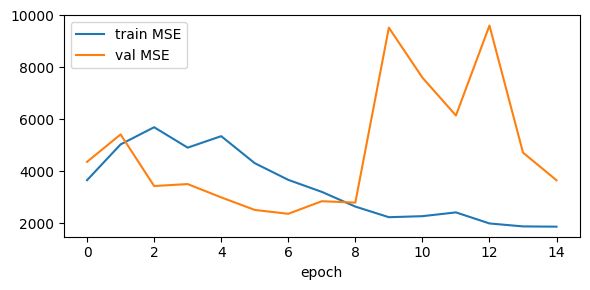

In [ ]:
try:
    import matplotlib.pyplot as plt

    plt.figure(figsize=(6, 3))
    plt.plot(history["train_mse"], label="train MSE")
    plt.plot(history["val_mse"], label="val MSE")
    plt.xlabel("epoch")
    plt.legend()
    plt.tight_layout()
    plt.show()
except ImportError:
    print("matplotlib not installed; skip plot.")